In [1]:
# setup: connect notebook to project root and import utilities

import sys
import os

sys.path.append(os.path.abspath(".."))

import importlib
import utils
importlib.reload(utils)

from utils import integrated_risk_score

# core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# creating synthetic dataset to simulate exposure conditions

data = pd.DataFrame({
    "AQI": np.random.randint(50, 300, 100),
    "smoking": np.random.randint(0, 2, 100),
    "exercise": np.random.randint(0, 5, 100)
})

data.head()

,AQI,smoking,exercise
0,181,0,2
1,244,1,0
2,231,1,4
3,240,1,1
4,249,0,1


In [3]:
# exposure score: higher value means worse environmental + lifestyle impact

def calculate_exposure_score(row):
    score = 0
    
    score += row["AQI"] * 0.5      # pollution impact
    score += row["smoking"] * 50   # smoking penalty
    score -= row["exercise"] * 10  # exercise benefit
    
    return score

data["exposure_score"] = data.apply(calculate_exposure_score, axis=1)

data.head()

,AQI,smoking,exercise,exposure_score
0,181,0,2,70.5
1,244,1,0,172.0
2,231,1,4,125.5
3,240,1,1,160.0
4,249,0,1,114.5


In [4]:
# classify exposure into risk categories

def risk_category(score):
    if score < 100:
        return "Low"
    elif score < 180:
        return "Moderate"
    else:
        return "High"

data["risk_category"] = data["exposure_score"].apply(risk_category)

data.head()

,AQI,smoking,exercise,exposure_score,risk_category
0,181,0,2,70.5,Low
1,244,1,0,172.0,Moderate
2,231,1,4,125.5,Moderate
3,240,1,1,160.0,Moderate
4,249,0,1,114.5,Moderate


In [5]:
# training model to predict exposure score from input features

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = data[["AQI", "smoking", "exercise"]]
y = data["exposure_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [6]:
# simulate a real user input

aqi = 180
smoking = 1
exercise = 0

exposure_score = model.predict([[aqi, smoking, exercise]])[0]

print("Exposure Score:", exposure_score)

Exposure Score: 116.78


/Users/shivalibajaj/git-portfolio/AirAware - Lung Health Intelligence System/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


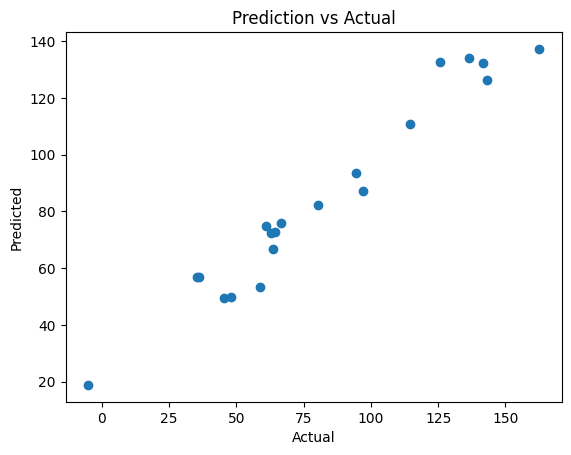

In [7]:
# compare predicted vs actual values

plt.scatter(y_test, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual")

plt.savefig("../figures/prediction_vs_actual.png")
plt.show()

In [8]:
# simulated lung features (these come from CT pipeline)

lung_density = 0.7
low_density_ratio = 0.3

In [9]:
# combining exposure + lung condition into final risk score

final_score = integrated_risk_score(
    exposure_score,
    lung_density,
    low_density_ratio
)

print("Final Score:", final_score)

Final Score: 288.39


In [10]:
# final classification based on integrated score

def final_risk(score):
    if score < 120:
        return "Low"
    elif score < 220:
        return "Moderate"
    else:
        return "High"

final_risk_category = final_risk(final_score)

print("Final Risk:", final_risk_category)

Final Risk: High


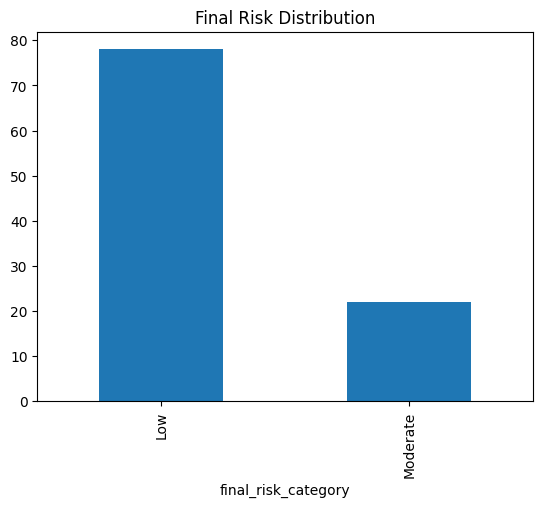

In [11]:
# visualize distribution (based on exposure score for simplicity)

data["final_risk_category"] = data["exposure_score"].apply(final_risk)

data["final_risk_category"].value_counts().plot(kind="bar")
plt.title("Final Risk Distribution")

plt.show()